In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [5]:
df = pd.read_csv("diabetes.csv")

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [12]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
X_train,X_test,y_train,y_test = train_test_split(
X_scaled,
y,
test_size=0.2,
random_state=42
)

In [15]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [16]:
dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)


In [17]:
rf = RandomForestClassifier()

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [18]:
print("Logistic Regression Accuracy")

print(accuracy_score(y_test,pred_lr))

Logistic Regression Accuracy
0.7532467532467533


In [19]:
print(accuracy_score(y_test,pred_dt))

0.7467532467532467


In [20]:
print(accuracy_score(y_test,pred_rf))


0.7662337662337663


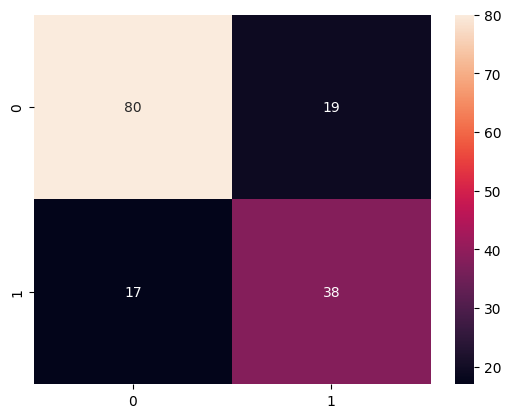

In [21]:
cm = confusion_matrix(y_test,pred_rf)

sns.heatmap(cm,
annot=True,
fmt='d')

plt.show()

In [22]:
print(classification_report(y_test,pred_rf))


              precision    recall  f1-score   support

           0       0.82      0.81      0.82        99
           1       0.67      0.69      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [23]:
importance = rf.feature_importances_

features = X.columns

feature_df = pd.DataFrame({
    "Feature":features,
    "Importance":importance
})

feature_df = feature_df.sort_values(
by="Importance",
ascending=False)

print(feature_df)

                    Feature  Importance
1                   Glucose    0.253158
5                       BMI    0.167465
7                       Age    0.141938
6  DiabetesPedigreeFunction    0.115596
2             BloodPressure    0.091671
0               Pregnancies    0.082920
4                   Insulin    0.074379
3             SkinThickness    0.072873


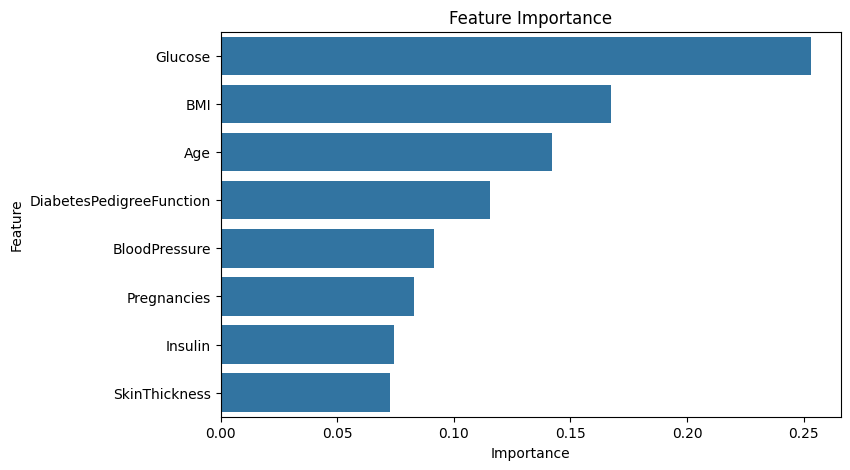

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
x="Importance",
y="Feature",
data=feature_df
)

plt.title("Feature Importance")

plt.show()

In [25]:
new_patient = [[2, 120, 70, 20, 85, 28.5, 0.45, 35]]

In [26]:
new_patient_scaled = scaler.transform(new_patient)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [27]:
prediction = rf.predict(new_patient_scaled)

if prediction[0] == 1:
    print("High Risk of Diabetes")
else:
    print("Low Risk of Diabetes")

Low Risk of Diabetes


In [28]:
preg = int(input("Pregnancies: "))
glu = float(input("Glucose: "))
bp = float(input("Blood Pressure: "))
skin = float(input("Skin Thickness: "))
insulin = float(input("Insulin: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = int(input("Age: "))

new_patient = [[preg, glu, bp, skin, insulin, bmi, dpf, age]]

new_patient_scaled = scaler.transform(new_patient)

prediction = rf.predict(new_patient_scaled)

if prediction[0] == 1:
    print("\n High Risk of Diabetes")
else:
    print("\n Low Risk of Diabetes")

Pregnancies: 2
Glucose: 150
Blood Pressure: 85
Skin Thickness: 30
Insulin: 130
BMI: 34
Diabetes Pedigree Function: 0.5
Age: 45

 High Risk of Diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
